## Importação das Dependências e Configurações

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


## Análise Inicial dos Datasets

In [3]:
df_avl_suspeitas = pd.read_csv("../data/projeto_02_avaliacoes_suspeitas.csv")
df_vendas = pd.read_csv("../data/projeto_02_ecommerce_vendas.csv")
df_vendedores = pd.read_csv("../data/projeto_02_vendedores_perfil.csv")

In [4]:
print("Invalidos")
verificados = pd.unique(df_vendedores['vendedor_id'].values)
nao_verificados = pd.unique(df_vendedores[df_vendedores['verificado'] == False]['vendedor_id'].values)

print(verificados.size)
print(verificados)
print("--------------------------------")
print("Invalidos")

print(nao_verificados.size)
print(nao_verificados)

Invalidos
120
['VEND-0001' 'VEND-0002' 'VEND-0003' 'VEND-0004' 'VEND-0005' 'VEND-0006'
 'VEND-0007' 'VEND-0008' 'VEND-0009' 'VEND-0010' 'VEND-0011' 'VEND-0012'
 'VEND-0013' 'VEND-0014' 'VEND-0015' 'VEND-0016' 'VEND-0017' 'VEND-0018'
 'VEND-0019' 'VEND-0020' 'VEND-0021' 'VEND-0022' 'VEND-0023' 'VEND-0024'
 'VEND-0025' 'VEND-0026' 'VEND-0027' 'VEND-0028' 'VEND-0029' 'VEND-0030'
 'VEND-0031' 'VEND-0032' 'VEND-0033' 'VEND-0034' 'VEND-0035' 'VEND-0036'
 'VEND-0037' 'VEND-0038' 'VEND-0039' 'VEND-0040' 'VEND-0041' 'VEND-0042'
 'VEND-0043' 'VEND-0044' 'VEND-0045' 'VEND-0046' 'VEND-0047' 'VEND-0048'
 'VEND-0049' 'VEND-0050' 'VEND-0051' 'VEND-0052' 'VEND-0053' 'VEND-0054'
 'VEND-0055' 'VEND-0056' 'VEND-0057' 'VEND-0058' 'VEND-0059' 'VEND-0060'
 'VEND-0061' 'VEND-0062' 'VEND-0063' 'VEND-0064' 'VEND-0065' 'VEND-0066'
 'VEND-0067' 'VEND-0068' 'VEND-0069' 'VEND-0070' 'VEND-0071' 'VEND-0072'
 'VEND-0073' 'VEND-0074' 'VEND-0075' 'VEND-0076' 'VEND-0077' 'VEND-0078'
 'VEND-0079' 'VEND-0080' 'VEND-0081' 

Amostras de Dados

In [5]:
df_vendedores.sample(5)

,vendedor_id,nome_loja,data_cadastro,cidade,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado
112,VEND-0113,Loja HQIPM,2021-06-17,Fortaleza,PI,Beleza & Saúde,825,4.0,4,False
11,VEND-0012,Loja SYTHA,2021-04-02,Rio de Janeiro,PE,Moda Masculina,1432,4.3,16,False
88,VEND-0089,Loja VTYJJ,2021-04-01,Manaus,SE,Moda Masculina,1283,4.1,12,False
25,VEND-0026,Loja DGMUU,2022-11-06,Rio de Janeiro,GO,Moda Feminina,1192,4.3,0,True
20,VEND-0021,Loja MLMJV,2022-01-08,São Paulo,BA,Esporte & Lazer,982,3.1,0,False


In [6]:
df_vendas.sample(5)

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao
1831,PED-001832,2024-10-25,09:12,VEND-0033,Esporte & Lazer,PROD-0452,186.72,2,373.44,42.58,RN,Devolvido,NaN
180,PED-000181,2023-12-09,12:17,VEND-0054,Beleza & Saúde,PROD-0341,71.27,1,71.27,5.71,SP,Entregue,5.0
2437,PED-002438,2024-05-06,14:09,VEND-0050,Eletrônicos,PROD-0235,653.37,1,653.37,35.64,CE,Em trânsito,NaN
1006,PED-001007,2024-08-27,08:28,VEND-0044,Eletrônicos,PROD-0355,15.97,1,15.97,37.37,MG,Entregue,5.0
1243,PED-001244,2024-12-29,08:05,VEND-0025,Casa & Decoração,PROD-0251,219.63,1,219.63,29.03,CE,Entregue,4.0


In [7]:
df_avl_suspeitas.sample(5)

,avaliacao_id,vendedor_id,comprador_id,data_avaliacao,data_criacao_conta,nota,ip_origem,texto_avaliacao
2375,AVAL-02376,VEND-0004,COMP-01461,2023-11-23,2021-12-03,5,1.67.235.15,NaN
2082,AVAL-02083,VEND-0058,COMP-02549,2023-07-20,2022-09-20,3,71.118.151.184,NaN
234,AVAL-00235,VEND-0036,COMP-00972,2023-10-06,2022-04-12,3,38.51.18.109,Não gostei da qualidade.
39,AVAL-00040,VEND-0033,COMP-01376,2023-08-28,2022-02-09,4,35.143.103.170,"Recomendo, boa experiência."
2389,AVAL-02390,VEND-0085,COMP-04332,2023-04-12,2021-09-09,5,229.165.247.35,"Produto ok, dentro do esperado."


Transformando_dados de Dados

In [8]:
df_vendas['data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendas['_hora_pedido'] = pd.to_datetime(df_vendas['hora_pedido'], format='%H:%M')

df_vendedores['data_cadastro_dt'] = pd.to_datetime(df_vendedores['data_cadastro'], format='%Y-%m-%d')

df_avl_suspeitas['data_avaliacao_dt'] = pd.to_datetime(df_avl_suspeitas['data_avaliacao'], format='%Y-%m-%d')
df_avl_suspeitas['data_criacao_conta_dt'] = pd.to_datetime(df_avl_suspeitas['data_criacao_conta'], format='%Y-%m-%d')

Investigações Base

0 - Validação da coluna "Verificado"

In [9]:
df_vendedores[['verificado']].value_counts(normalize='percent')

verificado
False         0.525
True          0.475
Name: proportion, dtype: float64

In [10]:
verificados = pd.unique(df_vendedores[df_vendedores['verificado'] == True]['vendedor_id'].values)
nao_verificados = pd.unique(df_vendedores[df_vendedores['verificado'] == False]['vendedor_id'].values)

print("Verificados")
print(verificados.size)
print(verificados)

print("--------------------------------")

print("Não Verificados")
print(nao_verificados.size)
print(nao_verificados)

print("\n")

print([x for x in verificados if x in nao_verificados])
print([x for x in nao_verificados if x in verificados])



Verificados
57
['VEND-0003' 'VEND-0006' 'VEND-0007' 'VEND-0009' 'VEND-0010' 'VEND-0015'
 'VEND-0016' 'VEND-0018' 'VEND-0019' 'VEND-0020' 'VEND-0022' 'VEND-0025'
 'VEND-0026' 'VEND-0027' 'VEND-0028' 'VEND-0029' 'VEND-0032' 'VEND-0041'
 'VEND-0047' 'VEND-0049' 'VEND-0050' 'VEND-0051' 'VEND-0053' 'VEND-0054'
 'VEND-0055' 'VEND-0057' 'VEND-0058' 'VEND-0059' 'VEND-0060' 'VEND-0062'
 'VEND-0063' 'VEND-0064' 'VEND-0065' 'VEND-0067' 'VEND-0071' 'VEND-0072'
 'VEND-0073' 'VEND-0074' 'VEND-0075' 'VEND-0077' 'VEND-0084' 'VEND-0085'
 'VEND-0086' 'VEND-0091' 'VEND-0092' 'VEND-0096' 'VEND-0098' 'VEND-0100'
 'VEND-0103' 'VEND-0107' 'VEND-0108' 'VEND-0109' 'VEND-0111' 'VEND-0112'
 'VEND-0116' 'VEND-0117' 'VEND-0118']
--------------------------------
Não Verificados
63
['VEND-0001' 'VEND-0002' 'VEND-0004' 'VEND-0005' 'VEND-0008' 'VEND-0011'
 'VEND-0012' 'VEND-0013' 'VEND-0014' 'VEND-0017' 'VEND-0021' 'VEND-0023'
 'VEND-0024' 'VEND-0030' 'VEND-0031' 'VEND-0033' 'VEND-0034' 'VEND-0035'
 'VEND-0036' 'VEND-

# 1. **Existem vendedores com padrão de vendas concentrado em horários atípicos** (madrugada, 2h-5h)? Quem são e qual o volume?

## Vendedores com horáios atipicos (2h-5h)

In [11]:
df_vendas_2_5 = df_vendas.query('_hora_pedido.dt.hour >= 2 and _hora_pedido.dt.hour <= 5')

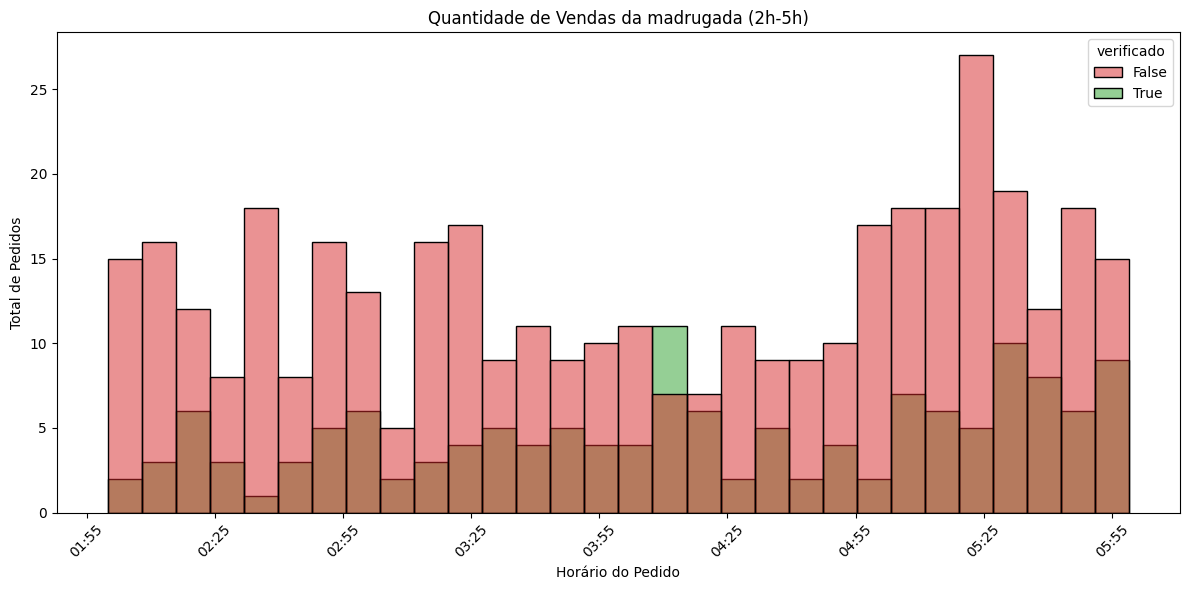

In [12]:
vendas_status_2_5 = df_vendas_2_5.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=vendas_status_2_5,
    x='_hora_pedido',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title("Quantidade de Vendas da madrugada (2h-5h)")
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

## Quantidade de Vendedores (Verificado x Não Verificado) por Hora do Pedido

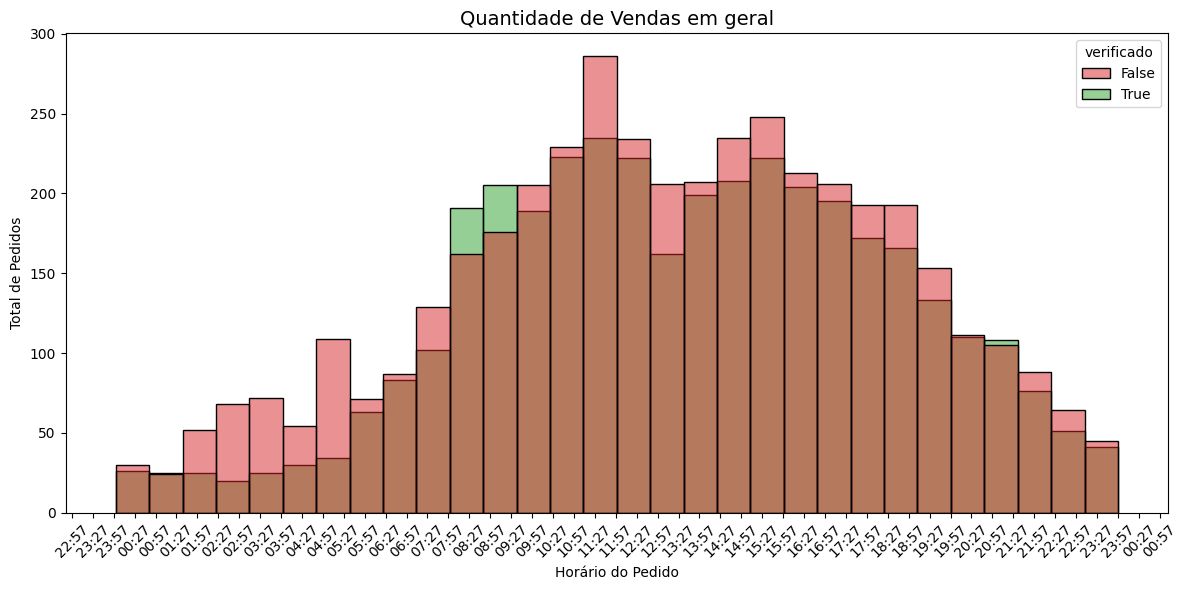

In [13]:
vendas_status_geral = df_vendas.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=vendas_status_geral,
    x='_hora_pedido',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title("Quantidade de Vendas em geral", fontsize=14)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Vendedor')

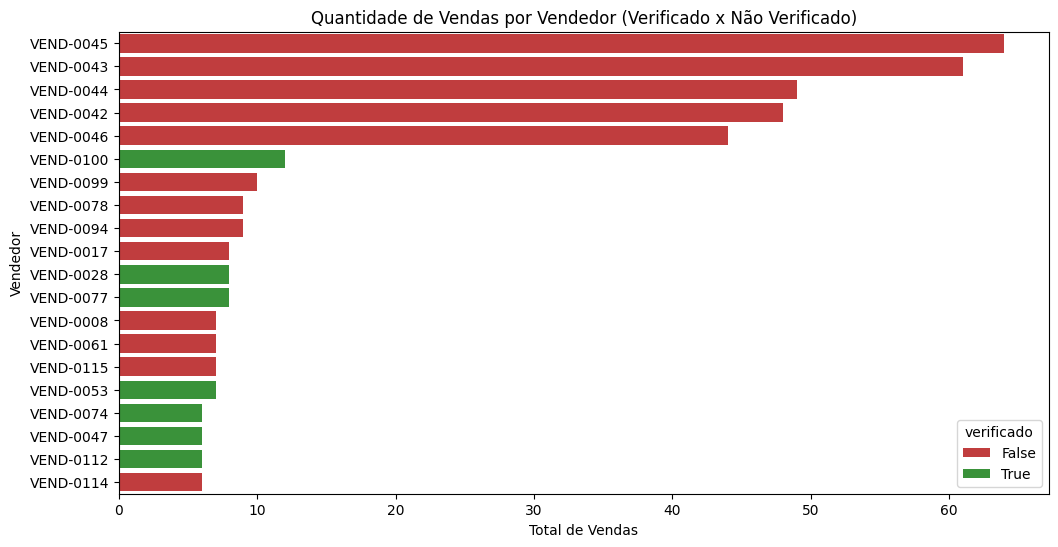

In [14]:
quantidade_vendas_por_vendedor = vendas_status_2_5.groupby(['vendedor_id', 'verificado']
                                                    )['quantidade'].sum().reset_index(name='total_vendas'
                                                    ).sort_values(by='total_vendas', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    quantidade_vendas_por_vendedor.head(20),
    x='total_vendas',
    y='vendedor_id',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)

plt.title("Quantidade de Vendas por Vendedor (Verificado x Não Verificado)")
plt.xlabel("Total de Vendas")
plt.ylabel("Vendedor")

# 2. **Há avaliações falsas?** Identifique padrões: contas criadas há poucos dias que avaliam com nota 5, IPs repetidos, textos idênticos.

Análise do Tempo de Criação da Conta

In [175]:
df_avl_suspeitas['tempo_criacao_conta'] = (
    df_avl_suspeitas['data_avaliacao_dt'] - df_avl_suspeitas['data_criacao_conta_dt']
).dt.days

In [176]:
df_avl_suspeitas['tempo_criacao_conta'].describe()

count    3000.000000
mean      366.727000
std       208.722885
min         1.000000
25%       188.000000
50%       365.000000
75%       548.000000
max       730.000000
Name: tempo_criacao_conta, dtype: float64

Distribuição do Tempo de Criação da Conta

<Axes: xlabel='tempo_criacao_conta', ylabel='Count'>

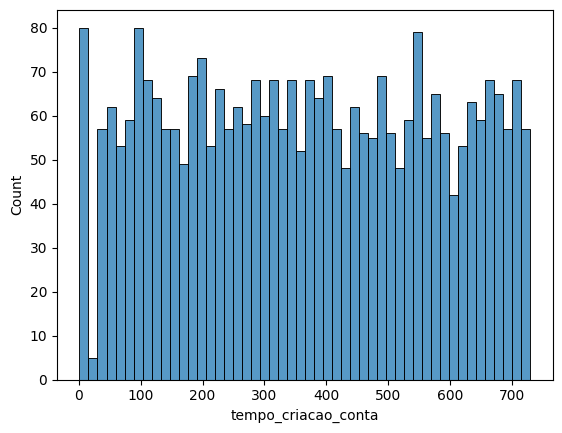

In [177]:
sns.histplot(data=df_avl_suspeitas['tempo_criacao_conta'], bins=50)

In [178]:
df_avl_suspeitas.groupby('vendedor_id')['tempo_criacao_conta'].median().reset_index(name='Mediana_Tempo_Criacao_Conta').sort_values(by='Mediana_Tempo_Criacao_Conta')

,vendedor_id,Mediana_Tempo_Criacao_Conta
45,VEND-0046,4.0
42,VEND-0043,5.0
44,VEND-0045,5.5
41,VEND-0042,6.0
43,VEND-0044,27.0
...,...,...
89,VEND-0090,488.5
15,VEND-0016,489.5
13,VEND-0014,492.0
79,VEND-0080,511.5


<Axes: ylabel='tempo_criacao_conta'>

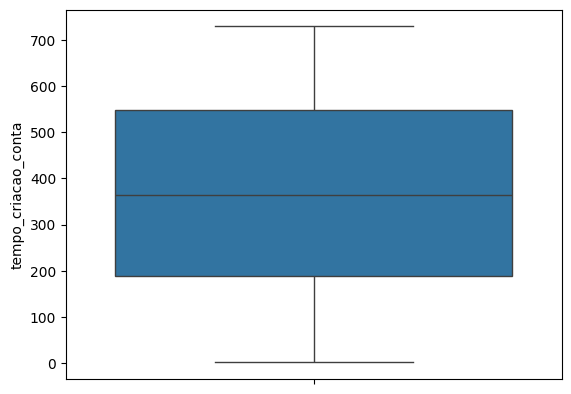

In [179]:
sns.boxplot(df_avl_suspeitas['tempo_criacao_conta'])

Merge com os Vendedores

In [180]:
df_avl_suspeitas_info = df_avl_suspeitas.merge(df_vendedores, 
                                               on='vendedor_id', how='left')

df_avl_suspeitas_info

,avaliacao_id,vendedor_id,comprador_id,data_avaliacao,data_criacao_conta,nota,ip_origem,texto_avaliacao,data_avaliacao_dt,data_criacao_conta_dt,...,nome_loja,data_cadastro,cidade,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado,data_cadastro_dt
0,AVAL-00001,VEND-0019,COMP-02695,2023-11-01,2022-10-19,5,178.78.250.151,"Produto ok, dentro do esperado.",2023-11-01,2022-10-19,...,Loja EPNPN,2022-03-05,Salvador,PE,Casa & Decoração,1575,2.9,23,True,2022-03-05
1,AVAL-00002,VEND-0118,COMP-00156,2023-10-20,2023-01-16,3,63.102.198.239,"Produto ok, dentro do esperado.",2023-10-20,2023-01-16,...,Loja TTRVV,2021-12-30,Belo Horizonte,MA,Acessórios,1107,4.3,26,True,2021-12-30
2,AVAL-00003,VEND-0107,COMP-01834,2024-11-18,2024-05-13,5,147.114.196.226,Bom produto pelo preço.,2024-11-18,2024-05-13,...,Loja VLJBA,2020-11-25,Manaus,MG,Eletrônicos,278,3.8,10,True,2020-11-25
3,AVAL-00004,VEND-0079,COMP-04229,2023-03-25,2022-04-03,5,92.235.229.225,"Produto ok, dentro do esperado.",2023-03-25,2022-04-03,...,Loja ZANLX,2020-09-10,Porto Alegre,MG,Esporte & Lazer,1765,4.3,18,False,2020-09-10
4,AVAL-00005,VEND-0117,COMP-02844,2023-08-28,2022-07-12,1,187.99.250.54,Não gostei da qualidade.,2023-08-28,2022-07-12,...,Loja AFRXX,2020-05-25,Brasília,RJ,Infantil,204,4.5,16,True,2020-05-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,AVAL-02996,VEND-0097,COMP-03864,2023-12-26,2023-09-25,4,26.178.153.226,NaN,2023-12-26,2023-09-25,...,Loja ATTPS,2022-01-04,Belo Horizonte,PI,Infantil,680,4.1,18,False,2022-01-04
2996,AVAL-02997,VEND-0043,COMP-01936,2023-07-29,2023-07-28,5,192.168.1.100,"Produto incrível, vendedor nota 10!",2023-07-29,2023-07-28,...,Loja XYZ04,2023-03-11,Fortaleza,CE,Casa & Decoração,1104,4.8,2,False,2023-03-11
2997,AVAL-02998,VEND-0013,COMP-04226,2024-12-17,2024-10-23,5,182.36.180.222,Excelente custo-benefício.,2024-12-17,2024-10-23,...,Loja YZZMG,2021-05-30,Belo Horizonte,PR,Moda Masculina,793,2.7,17,False,2021-05-30
2998,AVAL-02999,VEND-0050,COMP-02865,2023-01-09,2022-08-26,5,253.5.24.139,Demorou um pouco mas chegou bem.,2023-01-09,2022-08-26,...,Loja EPZCI,2022-03-07,Brasília,GO,Acessórios,1156,4.4,2,True,2022-03-07


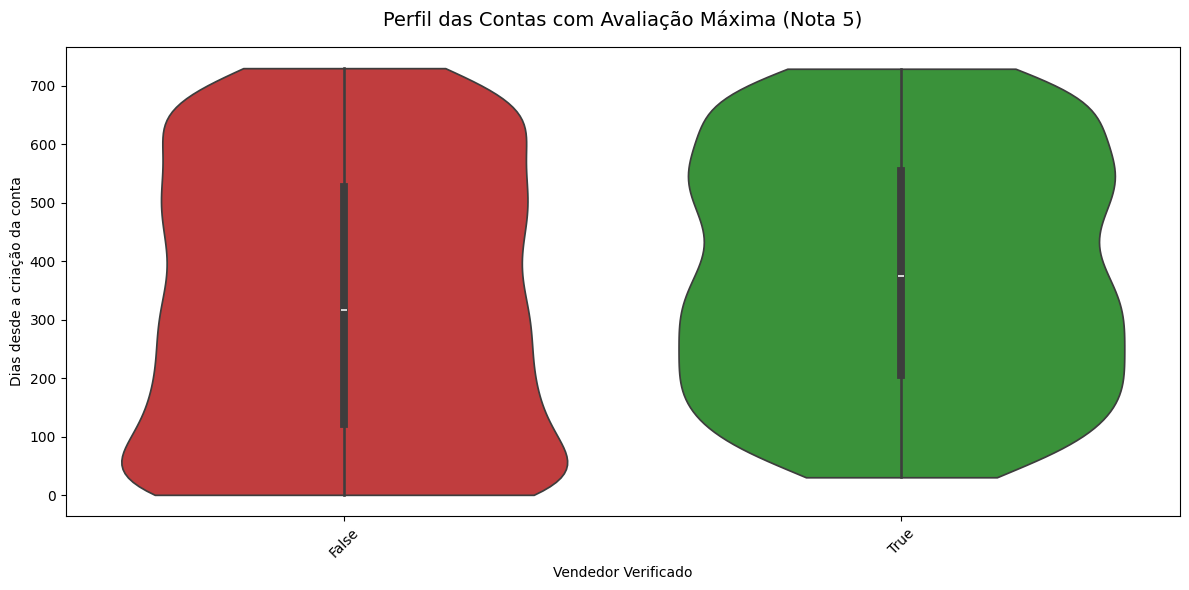

In [181]:
plt.figure(figsize=(12,6))
df_notas_5 = df_avl_suspeitas_info.query("nota == 5")

sns.violinplot(
    data=df_notas_5, 
    x='verificado',
    y='tempo_criacao_conta', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.xticks(rotation=45)
plt.ylabel('Dias desde a criação da conta')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

Quantidade de Ips Repetidos

Text(0, 0.5, 'Vendedor')

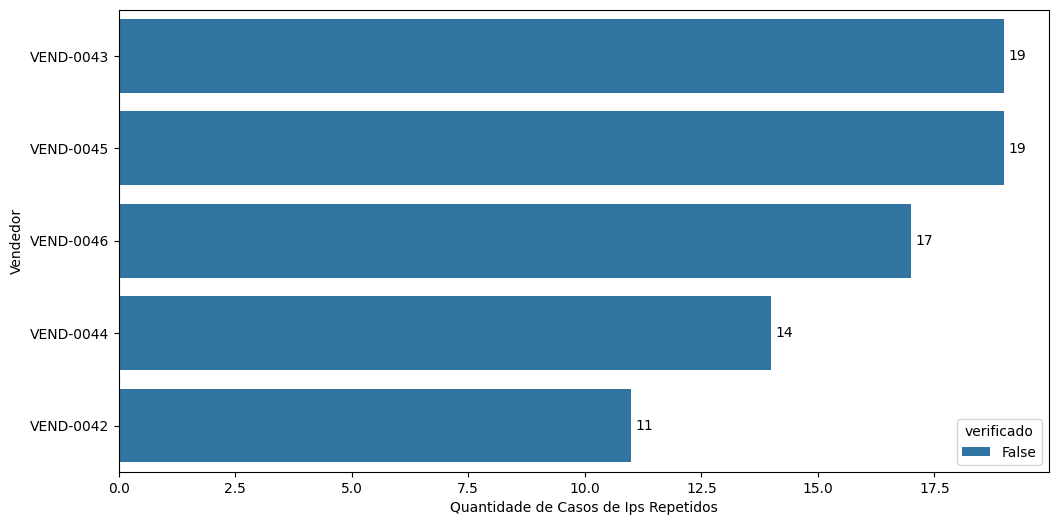

In [202]:
df_avl_suspeitas_info['possui_ips_repetidos'] = df_avl_suspeitas_info.groupby(
                                                            ["vendedor_id", "ip_origem"]
                                                    ).transform("size").map(lambda x: x > 1).astype("int")

df_casos_ips_repetidos = (
    df_avl_suspeitas_info.query("nota == 5").groupby(
        ["vendedor_id", "verificado"]
    )['possui_ips_repetidos'].sum().reset_index(name="soma_casos_ip_repetido").sort_values(
        by='soma_casos_ip_repetido', ascending=False
    ).query(
        "soma_casos_ip_repetido > 0"
    )
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
   df_casos_ips_repetidos,
    x='soma_casos_ip_repetido',
    y='vendedor_id',
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.xlabel("Quantidade de Casos de Ips Repetidos")
plt.ylabel("Vendedor")


Agrupamento por Texto de Avaliação

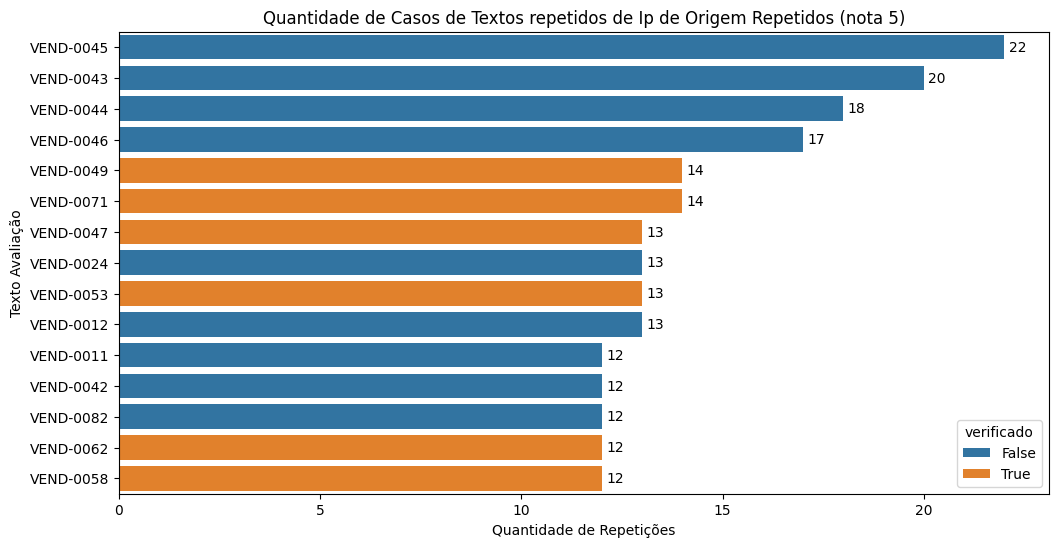

In [ ]:
df_avl_suspeitas_info['possui_textos_repetidos'] =  df_avl_suspeitas_info.groupby(
                                                            ["vendedor_id", "texto_avaliacao"]
                                                    ).transform("size").map(lambda x: x > 1).astype("int")

df_casos_texto_repetido = (
    df_avl_suspeitas_info.query("nota == 5").groupby(
        ["vendedor_id", "verificado"]
    )['possui_textos_repetidos'].sum().reset_index(name="soma_casos_texo_repetido").sort_values(
        by='soma_casos_texo_repetido', ascending=False
    ).query(
        "soma_casos_texo_repetido > 0"
    )
)

plt.figure(figsize=(12,6))

ax2 = sns.barplot(
    df_casos_texto_repetido.head(15),
    x='soma_casos_texo_repetido',
    y='vendedor_id',
    hue='verificado'
)

for container in ax2.containers:
    ax2.bar_label(container, padding=3, fontsize=10)

plt.title('Quantidade de Casos de Textos repetidos (nota 5)')
plt.xlabel("Quantidade de Repetições")
plt.ylabel("Vendedor")
plt.show()


Quantidade de Textos mais repetidos de nota 5

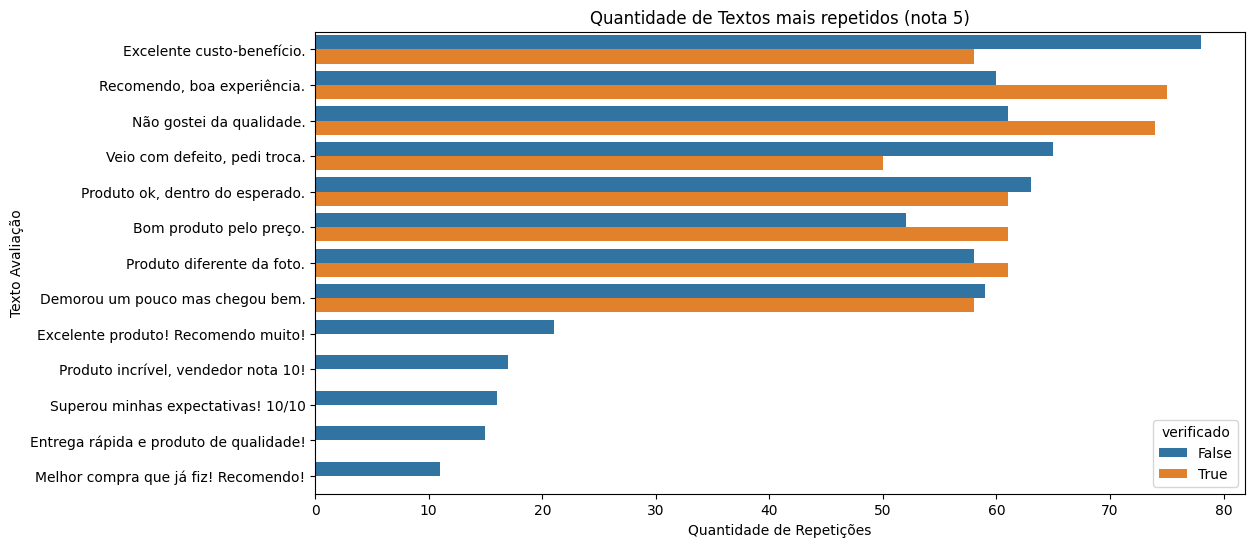

In [80]:
df_quant_textos = df_avl_suspeitas_info.query("nota == 5").groupby(
    ['texto_avaliacao', 'verificado']
).size().reset_index(name='contagem_texto_avaliacao').sort_values(by='contagem_texto_avaliacao', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    df_quant_textos,
    x='contagem_texto_avaliacao',
    y='texto_avaliacao',
    hue='verificado'
)

plt.title('Quantidade de Textos mais repetidos (nota 5)')
plt.xlabel("Quantidade de Repetições")
plt.ylabel("Texto Avaliação")
plt.show()


Quantidade de Categorias por Vendedor (Verificado x Não Verificado)

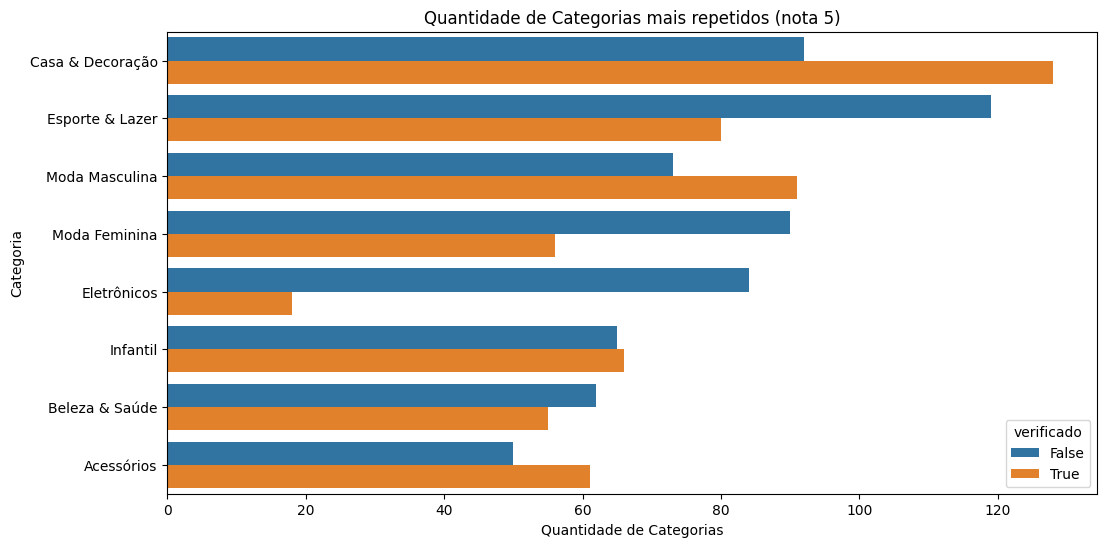

In [81]:
def_quant_categorias = df_avl_suspeitas_info.query("nota == 5").groupby(
    ['categoria_principal', 'verificado']
).size().reset_index(name='contagem_categorial_principal').sort_values(by='contagem_categorial_principal', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    def_quant_categorias,
    x='contagem_categorial_principal',
    y='categoria_principal',
    hue='verificado'
)

plt.title('Quantidade de Categorias mais repetidos (nota 5)')
plt.xlabel("Quantidade de Categorias")
plt.ylabel("Categoria")
plt.show()

Vendedores Suspeitos

In [222]:
df_avl_suspeitas_info['score'] = (df_avl_suspeitas_info['possui_ips_repetidos'] 
                                  + df_avl_suspeitas_info['possui_textos_repetidos'] 
                                  + (df_avl_suspeitas_info['nota'] == 5).astype("int")
                                  )

In [226]:
vendedores_suspeitos = df_avl_suspeitas_info[df_avl_suspeitas_info['score'] > 1]
vendedores_suspeitos

,avaliacao_id,vendedor_id,comprador_id,data_avaliacao,data_criacao_conta,nota,ip_origem,texto_avaliacao,data_avaliacao_dt,data_criacao_conta_dt,...,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado,data_cadastro_dt,possui_ips_repetidos,possui_textos_repetidos,score
0,AVAL-00001,VEND-0019,COMP-02695,2023-11-01,2022-10-19,5,178.78.250.151,"Produto ok, dentro do esperado.",2023-11-01,2022-10-19,...,PE,Casa & Decoração,1575,2.9,23,True,2022-03-05,0,1,2
2,AVAL-00003,VEND-0107,COMP-01834,2024-11-18,2024-05-13,5,147.114.196.226,Bom produto pelo preço.,2024-11-18,2024-05-13,...,MG,Eletrônicos,278,3.8,10,True,2020-11-25,0,1,2
3,AVAL-00004,VEND-0079,COMP-04229,2023-03-25,2022-04-03,5,92.235.229.225,"Produto ok, dentro do esperado.",2023-03-25,2022-04-03,...,MG,Esporte & Lazer,1765,4.3,18,False,2020-09-10,0,1,2
9,AVAL-00010,VEND-0006,COMP-01748,2024-06-22,2023-04-26,5,169.126.196.218,Não gostei da qualidade.,2024-06-22,2023-04-26,...,PR,Moda Masculina,448,3.0,15,True,2021-09-11,0,1,2
12,AVAL-00013,VEND-0003,COMP-03982,2023-03-02,2021-03-31,5,96.203.54.24,"Veio com defeito, pedi troca.",2023-03-02,2021-03-31,...,RJ,Moda Feminina,406,3.2,30,True,2021-08-25,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2991,AVAL-02992,VEND-0044,COMP-02726,2024-06-28,2024-06-22,5,192.168.1.102,Excelente produto! Recomendo muito!,2024-06-28,2024-06-22,...,CE,Esporte & Lazer,1388,4.9,0,False,2023-03-12,1,1,3
2993,AVAL-02994,VEND-0083,COMP-03992,2023-10-30,2022-02-17,5,68.147.127.249,Produto diferente da foto.,2023-10-30,2022-02-17,...,BA,Moda Masculina,194,3.3,13,False,2022-10-16,0,1,2
2996,AVAL-02997,VEND-0043,COMP-01936,2023-07-29,2023-07-28,5,192.168.1.100,"Produto incrível, vendedor nota 10!",2023-07-29,2023-07-28,...,CE,Casa & Decoração,1104,4.8,2,False,2023-03-11,1,1,3
2997,AVAL-02998,VEND-0013,COMP-04226,2024-12-17,2024-10-23,5,182.36.180.222,Excelente custo-benefício.,2024-12-17,2024-10-23,...,PR,Moda Masculina,793,2.7,17,False,2021-05-30,0,1,2


## OBS: Ainda falta a questão da data de avaliação mais recente

## 3. **Os vendedores suspeitos compartilham características em comum?** Cruze com o cadastro: data de cadastro próxima, mesma cidade, nomes similares, não verificados.

In [239]:
df_suspeitos = vendedores_suspeitos[['vendedor_id', 'data_cadastro', 'cidade', 'estado', 'nome_loja', 'verificado']].drop_duplicates().reset_index().drop(columns={'index'})

In [240]:
df_suspeitos['semana'] = pd.to_datetime(df_suspeitos['data_cadastro']).dt.isocalendar().week

# OBS: Está tendo um problema na nomenclatura dos dados de Estado

Mesmas Cidades/Estados

In [244]:
df_suspeitos.groupby(['cidade', 'estado']).size().sort_values(ascending=False)

cidade          estado
Fortaleza       CE        6
Brasília        BA        4
Belo Horizonte  MA        3
Brasília        CE        3
Belo Horizonte  PA        3
                         ..
São Paulo       CE        1
                MA        1
                GO        1
                RJ        1
                PR        1
Length: 81, dtype: int64

Nomes de Loja Repetidos

In [245]:
df_suspeitos.groupby(['nome_loja']).size().sort_values(ascending=False)

nome_loja
Loja XYZ02    2
Loja AFRXX    1
Loja AAKLQ    1
Loja ANMZH    1
Loja ATTPS    1
             ..
Loja YSHDL    1
Loja YXORT    1
Loja YZZMG    1
Loja ZANLX    1
Loja ZWGLY    1
Length: 119, dtype: int64

Mesmas Semanas/Datas de Criação

In [248]:
df_suspeitos.groupby(['semana', 'data_cadastro', 'vendedor_id']).size().sort_values(ascending=False)

semana  data_cadastro  vendedor_id
1       2021-01-08     VEND-0075      1
        2022-01-04     VEND-0097      1
        2022-01-07     VEND-0048      1
        2022-01-08     VEND-0021      1
2       2022-01-11     VEND-0077      1
                                     ..
48      2022-11-29     VEND-0002      1
        2022-11-30     VEND-0017      1
50      2021-12-15     VEND-0030      1
51      2021-12-20     VEND-0080      1
52      2021-12-30     VEND-0118      1
Length: 120, dtype: int64

## 4. **Qual o impacto financeiro** das vendas dos vendedores suspeitos? Quanto representam do faturamento total?

## 5. **A taxa de cancelamento/devolução** dos vendedores suspeitos é diferente dos demais?

## 6. **Construa um "score de risco"** baseado nos indicadores encontrados. Quais critérios compõem esse score?


## 7. **Proponha regras automáticas** para detectar fraudes futuras baseadas nos padrões descobertos.
